In [1]:
import pandas as pd
import numpy as np
import sqlite3

np.random.seed(42)

In [2]:
# CREATE WORKFLOW DATASET

df = pd.DataFrame({
    "ticket_id": range(1, 201),
    "priority": np.random.choice(["High", "Medium", "Low"], 200),
    "status": np.random.choice(["Open", "In Progress", "Closed"], 200),
    "sla_days": np.random.randint(1, 10, 200),
    "actual_days": np.random.randint(1, 15, 200)
})


In [3]:
# SLA ANALYSIS

df["sla_breached"] = df["actual_days"] > df["sla_days"]

sla_summary = df.groupby("priority")["sla_breached"].mean().reset_index()

print(sla_summary)


  priority  sla_breached
0     High      0.590909
1      Low      0.643836
2   Medium      0.540984


In [4]:
# SQLITE WORKFLOW TRACKING

conn = sqlite3.connect("workflow.db")
df.to_sql("workflow", conn, if_exists="replace", index=False)

query = """
SELECT status, COUNT(*) as count
FROM workflow
GROUP BY status
"""

status_summary = pd.read_sql(query, conn)
print(status_summary)

        status  count
0       Closed     66
1  In Progress     65
2         Open     69


In [5]:
# EXPORTING RESULTS

df.to_csv("workflow_data.csv", index=False)
sla_summary.to_csv("sla_summary.csv", index=False)

In [6]:
import matplotlib.pyplot as plt

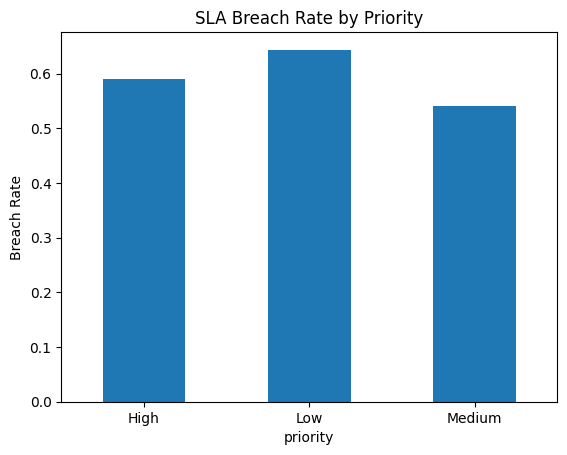

In [7]:
# SLA BREACH RATE

sla_rate = df.groupby("priority")["sla_breached"].mean()

plt.figure()
sla_rate.plot(kind="bar")
plt.title("SLA Breach Rate by Priority")
plt.ylabel("Breach Rate")
plt.xticks(rotation=0)
plt.show()

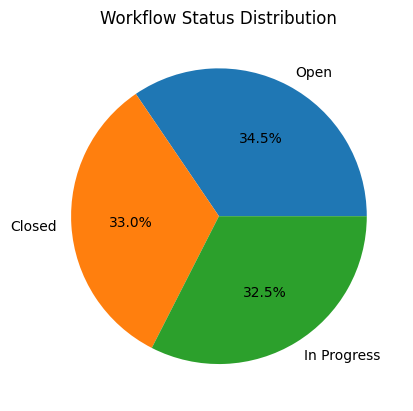

In [8]:
# STATUS DISTRIBUTION

plt.figure()
df["status"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Workflow Status Distribution")
plt.ylabel("")
plt.show()

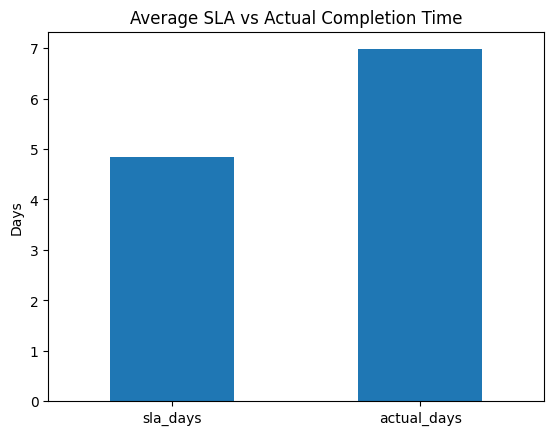

In [9]:
# SLA vs ACTUAL COMPARISON

avg_times = df[["sla_days", "actual_days"]].mean()

plt.figure()
avg_times.plot(kind="bar")
plt.title("Average SLA vs Actual Completion Time")
plt.ylabel("Days")
plt.xticks(rotation=0)
plt.show()